# 1. First Steps

Importing, first look and basic EDA

In [ ]:
# Importing all required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

# Reading in our dataset
df = pd.read_csv('aug_train.csv', sep=',')

In [ ]:
# First look at the dataframe
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
# Basic EDA
print('Overall Dataset Information:')
print(df.info())
print('\n')
print('Missing Data for each Row')
print(df.isnull().sum())
print('\n')
print('Dataset Summary Statistics')
print(df.describe())

Overall Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float6

Observations:

* Data Types are all either float, int or object. Objects will have to be normalised and later encoded as numerical representations.
* Missing data for 8 fields.
* Regarding standardisation of numerical variables, this could be a good idea since city_development_index and training_hours are on different scales.

In [ ]:
# Checking for all possible unique values in each column (looking for outliers or issues)
for i in df.columns:
  print(i+':')
  print(df[i].unique())
  print('\n')

enrollee_id:
[ 8949 29725 11561 ... 24576  5756 23834]


city:
['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79'

In [ ]:
# Creating a separate dataframe with which to analyse experience
df_exp = df.copy()

# Converting 'experience' to numerical, handling special strings and NaNs
# Assign 0 for '<1' and 21 for '>20'
df_exp['experience'] = df_exp['experience'].replace({'<1': 0, '>20': 21})
df_exp['experience'] = pd.to_numeric(df_exp['experience'], errors='coerce')
df_exp.dropna(subset=['experience'], inplace=True)

# Converting other numeric columns to proper types (already largely numeric, but good practice)
df_exp['training_hours'] = pd.to_numeric(df_exp['training_hours'], errors='coerce')
df_exp['city_development_index'] = pd.to_numeric(df_exp['city_development_index'], errors='coerce')
df_exp['target'] = pd.to_numeric(df_exp['target'], errors='coerce')

# 2. Normalisation

We have several numerical fields that contain symbols which is turning them categorical, we need to find different ways to solve this.

### experience

Usually this field would be converted to numerical once some of the values would have been standardised. However, while <1 is easy enough to replace with 0, we cannot do the same for \>20 as this would either influence the relationships too much (if we were to impute based on that) or introduce bias into the model by favouring higher values.

As such the only viable strategy is to turn this into a set of ranges, similar to the field "company size".

In [ ]:
# Defining a function to categorize experience into ranges
def categorize_experience_to_ranges(exp):
  try:
    # Converting strings to comparable ints
    exp_val = int(float(exp))
    if 1 <= exp_val <= 5:
      return '1-5'
    elif 6 <= exp_val <= 10:
       return '6-10'
    elif 11 <= exp_val <= 15:
       return '11-15'
    elif 16 <= exp_val <= 20:
       return '16-20'
    else:
       return str(exp) # Fallback for unexpected numeric values
  except ValueError:
    return str(exp) # Fallback for non-numeric values ('not provided' etc.)

# Apply the categorization function to the 'experience' column
df['experience'] = df['experience'].apply(categorize_experience_to_ranges)

### company_size

Simply need to change the instance showing '10/49' into '10-49'.

In [ ]:
# Replacing te single instance of 'Oct-49' with '10-49'
df.loc[df['company_size']=='Oct-49', 'company_size'] = '10-49'

# 3. Visualisations

Investigating the relationships between features and other features / target column.

Dataset Overview
Shape: (19158, 14)
Enrollment Rate: 24.9%



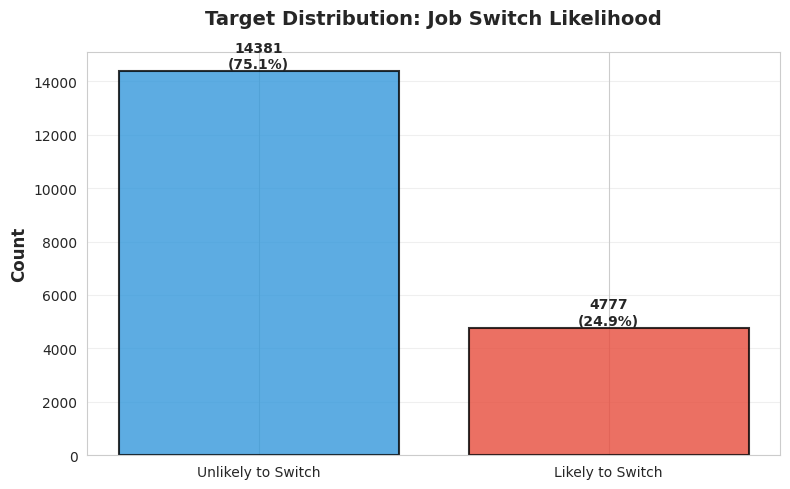

In [ ]:
# Set professional style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'

print("Dataset Overview")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Enrollment Rate: {df['target'].mean():.1%}\n")

# ============================================================================
# 1. TARGET OVERVIEW
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
target_data = df['target'].value_counts().sort_index()
colors = ['#3498db', '#e74c3c']
bars = ax.bar(['Unlikely to Switch', 'Likely to Switch'], target_data.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df):.1%})',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Target Distribution: Job Switch Likelihood', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

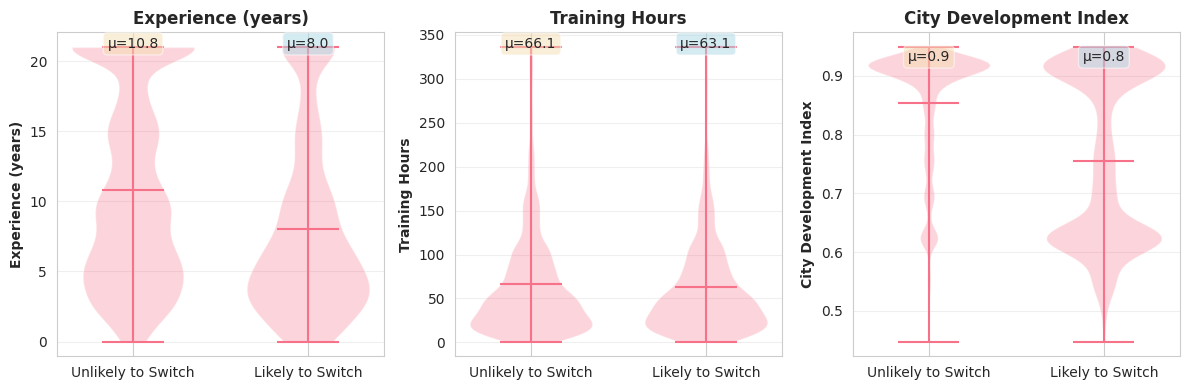

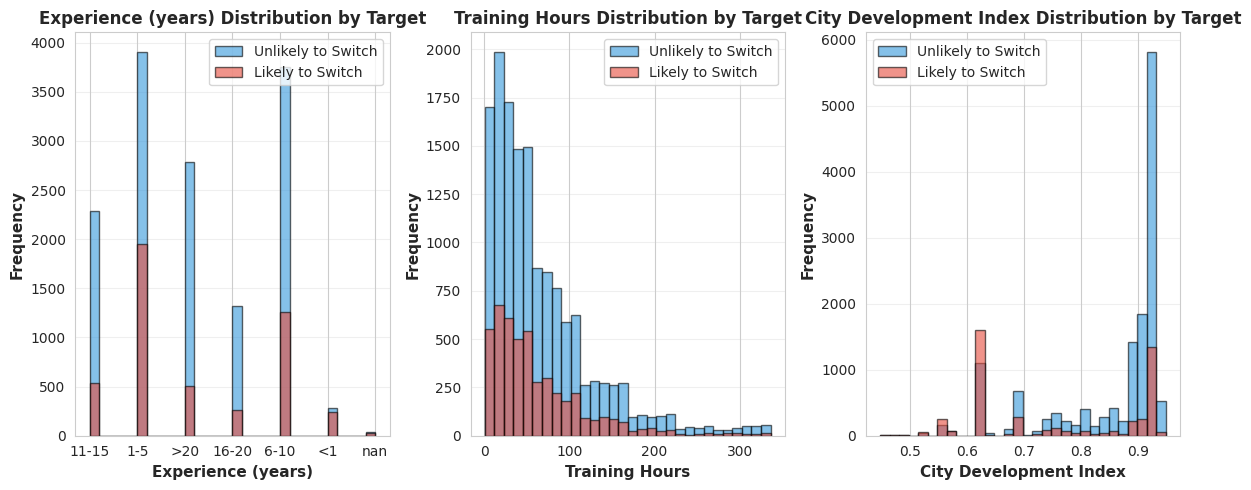

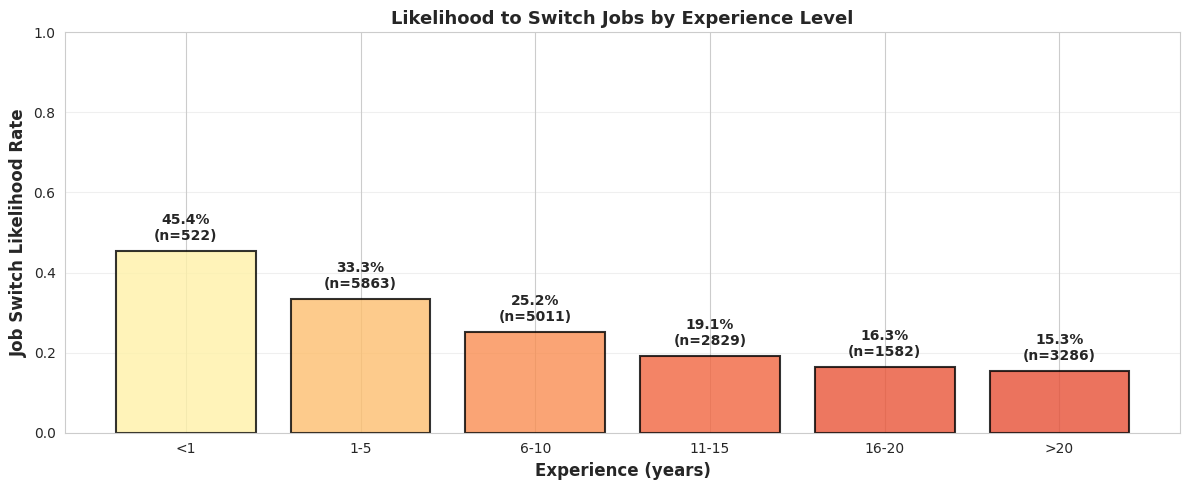

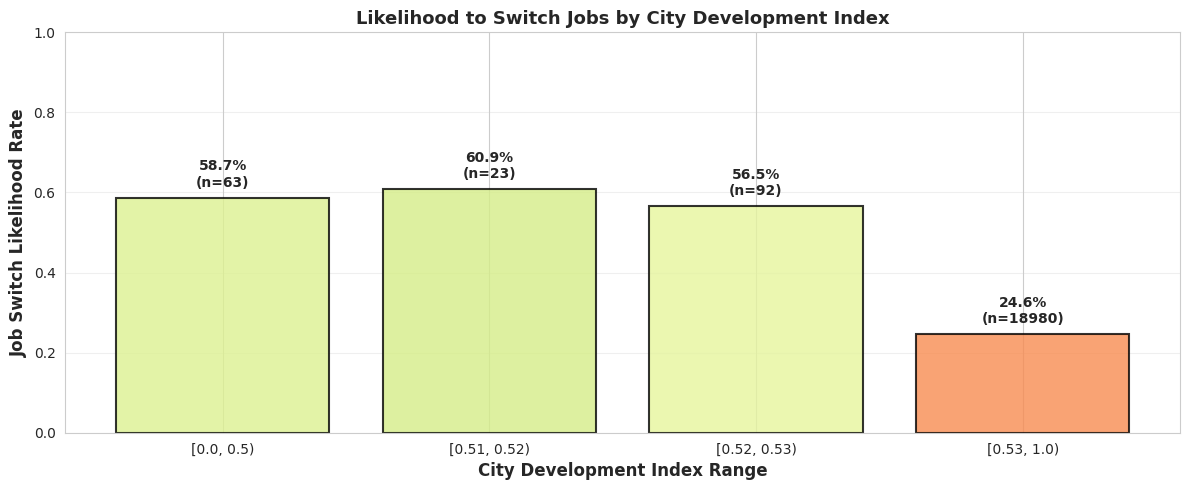

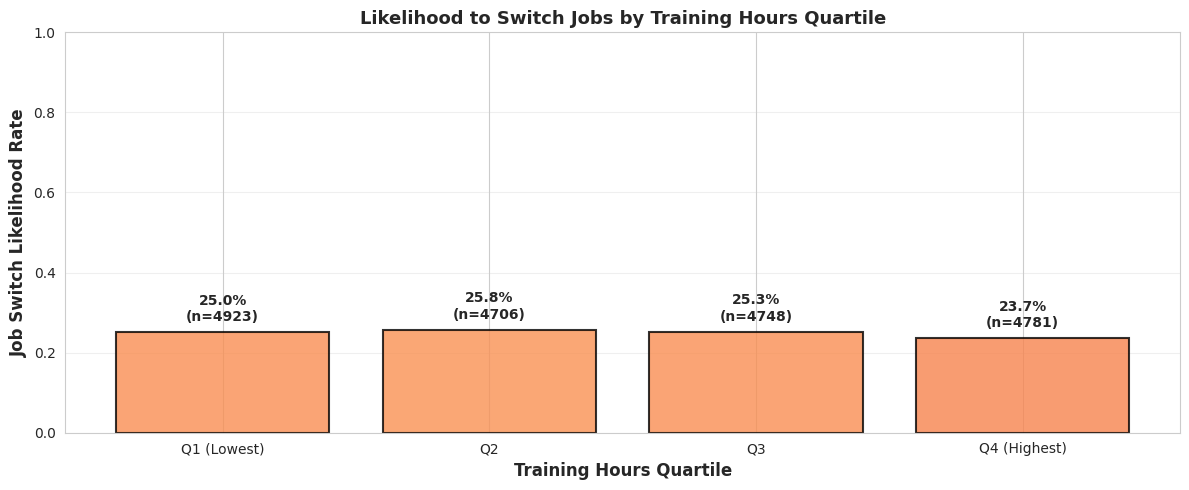

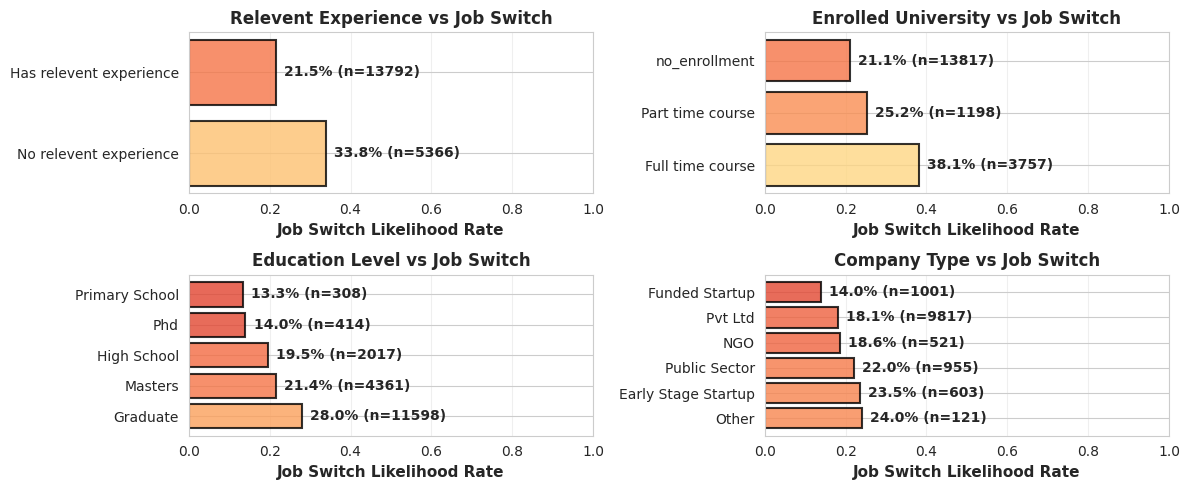

In [ ]:
# ============================================================================
# 2. NUMERICAL FEATURES vs TARGET
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

numerical_features = [
    ('experience', 'Experience (years)'),
    ('training_hours', 'Training Hours'),
    ('city_development_index', 'City Development Index')
]

for idx, (col, title) in enumerate(numerical_features):
    ax = axes[idx]

    # Get data and ensure numeric
    data_0 = pd.to_numeric(df_exp[df_exp['target']==0][col], errors='coerce').dropna().values
    data_1 = pd.to_numeric(df_exp[df_exp['target']==1][col], errors='coerce').dropna().values

    if len(data_0) > 0 and len(data_1) > 0:
        parts = ax.violinplot([data_0, data_1],
                               positions=[0, 1], showmeans=True, widths=0.7)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Unlikely to Switch', 'Likely to Switch'])
        ax.set_ylabel(title, fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3)

        # Calculate and display statistics
        mean_0 = np.nanmean(data_0)
        mean_1 = np.nanmean(data_1)
        ax.text(0, ax.get_ylim()[1]*0.95, f'μ={mean_0:.1f}', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.text(1, ax.get_ylim()[1]*0.95, f'μ={mean_1:.1f}', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()
print('\n')
# ============================================================================
# 3. NUMERICAL FEATURES vs TARGET (DISTRIBUTION ANALYSIS)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

num_features_dist = [
    ('experience', 'Experience (years)'),
    ('training_hours', 'Training Hours'),
    ('city_development_index', 'City Development Index')
]

for idx, (col, title) in enumerate(num_features_dist):
    ax = axes[idx]

    data_0 = df[df['target']==0][col].dropna()
    data_1 = df[df['target']==1][col].dropna()

    ax.hist(data_0, bins=30, alpha=0.6, label='Unlikely to Switch', color='#3498db', edgecolor='black')
    ax.hist(data_1, bins=30, alpha=0.6, label='Likely to Switch', color='#e74c3c', edgecolor='black')

    ax.set_xlabel(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{title} Distribution by Target', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('\n')
# ============================================================================
# 4. EXPERIENCE vs TARGET
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Define the custom order for 'experience' categories as they are already binned into strings
experience_order = ['<1', '1-5', '6-10', '11-15', '16-20', '>20', 'Not Provided']

# Convert 'experience' to a Categorical type with the custom order
df['experience'] = pd.Categorical(df['experience'], categories=experience_order, ordered=True)

# Calculate enrollment rate by experience
enroll_by_exp = df.groupby('experience', observed=False)['target'].agg(['sum', 'count', 'mean']).reset_index()
enroll_by_exp.columns = ['Experience', 'Enrolled_Count', 'Total', 'Enrollment_Rate']

colors_exp = plt.cm.RdYlGn(enroll_by_exp['Enrollment_Rate'].values)
bars = ax.bar(enroll_by_exp['Experience'].astype(str), enroll_by_exp['Enrollment_Rate'],
              color=colors_exp, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add labels
for bar, rate, count in zip(bars, enroll_by_exp['Enrollment_Rate'], enroll_by_exp['Total']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{rate:.1%}\n(n={int(count)})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Experience (years)', fontweight='bold', fontsize=12)
ax.set_ylabel('Job Switch Likelihood Rate', fontweight='bold', fontsize=12)
ax.set_title('Likelihood to Switch Jobs by Experience Level', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('\n')
# ============================================================================
# 5. CITY DEVELOPMENT INDEX vs TARGET
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Group by city development index (create bins)
cdi_bins = [0, 0.5, 0.51, 0.52, 0.53, 1.0]
cdi_labels = ['0.44-0.50', '0.50-0.51', '0.51-0.52', '0.52-0.53', '0.53+']
df['cdi_bin'] = pd.cut(df['city_development_index'], bins=cdi_bins, right=False)

# Calculate enrollment rate
enroll_by_cdi = df.groupby('cdi_bin', observed=True)['target'].agg(['sum', 'count', 'mean']).reset_index()
enroll_by_cdi.columns = ['CDI_Range', 'Enrolled_Count', 'Total', 'Enrollment_Rate']

colors_cdi = plt.cm.RdYlGn(enroll_by_cdi['Enrollment_Rate'].values)
bars = ax.bar(enroll_by_cdi['CDI_Range'].astype(str), enroll_by_cdi['Enrollment_Rate'],
              color=colors_cdi, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add labels
for bar, rate, count in zip(bars, enroll_by_cdi['Enrollment_Rate'], enroll_by_cdi['Total']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{rate:.1%}\n(n={int(count)})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('City Development Index Range', fontweight='bold', fontsize=12)
ax.set_ylabel('Job Switch Likelihood Rate', fontweight='bold', fontsize=12)
ax.set_title('Likelihood to Switch Jobs by City Development Index', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('\n')
# ============================================================================
# 6. TRAINING HOURS vs TARGET
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Create quartiles for training hours
df['train_quartile'] = pd.qcut(df['training_hours'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'], duplicates='drop')

enroll_by_train = df.groupby('train_quartile', observed=True)['target'].agg(['sum', 'count', 'mean']).reset_index()
enroll_by_train.columns = ['Training_Quartile', 'Enrolled_Count', 'Total', 'Enrollment_Rate']

colors_train = plt.cm.RdYlGn(enroll_by_train['Enrollment_Rate'].values)
bars = ax.bar(enroll_by_train['Training_Quartile'].astype(str), enroll_by_train['Enrollment_Rate'],
              color=colors_train, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add labels
for bar, rate, count in zip(bars, enroll_by_train['Enrollment_Rate'], enroll_by_train['Total']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{rate:.1%}\n(n={int(count)})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Training Hours Quartile', fontweight='bold', fontsize=12)
ax.set_ylabel('Job Switch Likelihood Rate', fontweight='bold', fontsize=12)
ax.set_title('Likelihood to Switch Jobs by Training Hours Quartile', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('\n')
# ============================================================================
# 7. CATEGORICAL FEATURES vs TARGET
# ============================================================================

categorical_features = [
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'company_type'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    ax = axes[idx]

    # Calculate enrollment rate
    enroll_rate = df.groupby(col)['target'].agg(['sum', 'count', 'mean']).reset_index()
    enroll_rate.columns = [col, 'Switch_Count', 'Total', 'Switch_Rate']
    enroll_rate = enroll_rate.sort_values('Switch_Rate', ascending=False)

    # Create color gradient
    colors_cat = plt.cm.RdYlGn(enroll_rate['Switch_Rate'].values)

    bars = ax.barh(enroll_rate[col].astype(str), enroll_rate['Switch_Rate'], color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)

    # Add percentage labels
    for i, (bar, rate, count) in enumerate(zip(bars, enroll_rate['Switch_Rate'], enroll_rate['Total'])):
        ax.text(rate + 0.02, bar.get_y() + bar.get_height()/2,
                f'{rate:.1%} (n={int(count)})',
                va='center', fontweight='bold', fontsize=10)

    ax.set_xlabel('Job Switch Likelihood Rate', fontweight='bold', fontsize=11)
    ax.set_title(col.replace('_', ' ').title() + ' vs Job Switch', fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 6. STATISTICAL SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

print("\nNUMERICAL FEATURES - Correlation with Target:")
print("-" * 60)

num_cols = ['experience', 'training_hours', 'city_development_index']
for col in num_cols:
    if col in df_exp.columns:
        valid_idx = df_exp[col].notna() & df_exp['target'].notna()
        if valid_idx.sum() > 0:
            x_vals = df_exp.loc[valid_idx, col].values
            y_vals = df_exp.loc[valid_idx, 'target'].values
            corr, p_val = pointbiserialr(y_vals, x_vals)
            significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            print(f"{col:30s}: r = {corr:7.4f} {significance} (p={p_val:.4e})")

print("\nCATEGORICAL FEATURES - Association with Target (Chi-Square):")
print("-" * 60)

assoc_scores = []
for col in categorical_features:
    if col in df.columns and df[col].notna().sum() > 0:
        ct = pd.crosstab(df[col], df['target'])
        chi2, p_val, dof, expected = chi2_contingency(ct)
        n = ct.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if min(ct.shape) > 1 else 0
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        assoc_scores.append((col, cramers_v, p_val))
        print(f"{col:30s}: V = {cramers_v:7.4f} {significance} (p={p_val:.4e})")

assoc_scores.sort(key=lambda x: x[1], reverse=True)

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print("\n✓ Most Important Features (by association strength):")
for i, (feat, score, _) in enumerate(assoc_scores[:3], 1):
    print(f"  {i}. {feat.replace('_', ' ').title()}: {score:.4f}")


STATISTICAL ANALYSIS

NUMERICAL FEATURES - Correlation with Target:
------------------------------------------------------------
experience                    : r = -0.1767 *** (p=9.4959e-134)
training_hours                : r = -0.0219 ** (p=2.4547e-03)
city_development_index        : r = -0.3418 *** (p=0.0000e+00)

CATEGORICAL FEATURES - Association with Target (Chi-Square):
------------------------------------------------------------
relevent_experience           : V =  0.1283 *** (p=1.5007e-70)
enrolled_university           : V =  0.1557 *** (p=1.4514e-99)
education_level               : V =  0.0941 *** (p=8.9490e-35)
company_type                  : V =  0.0519 *** (p=1.4803e-06)

KEY FINDINGS

✓ Most Important Features (by association strength):
  1. Enrolled University: 0.1557
  2. Relevent Experience: 0.1283
  3. Education Level: 0.0941


Comprehensive Workforce Retention Insights
Critical Experience Curve

Highest flight risk in first year: 42.4% likelihood to switch drops dramatically as tenure increases
Sweet spot at 10-19 years: Lowest attrition at 18.5%, representing the most stable, loyal workforce segment
Unexpected uptick after 20 years: Risk rises to 22.3%, possibly indicating pre-retirement job shopping or burnout
Mid-career vulnerability: The 2-9 year range (33.7% to 26.9%) represents a critical retention window

Geographic Paradox

Underdeveloped areas show extreme flight risk: 58-61% likelihood in cities with development index below 0.53
Dramatic stabilization in developed cities: Only 24.6% risk in highly developed areas (0.53-1.0 index)
Small sample sizes in underdeveloped regions suggest talent concentration in urban centers, with those in less developed areas actively seeking better opportunities

Education & Development Patterns

Graduate degree holders most likely to leave: 28% switch rate—likely due to better market options and higher expectations
PhD retention surprisingly weak: 14% despite advanced credentials, possibly due to limited specialized roles
High school educated workers more stable: 19.5% rate suggests fewer external opportunities or career mobility
Education creates mobility: More credentials = more options = higher turnover

Continuous Learning as Differentiator

Full-time university enrollment signals departure intent: 38.1% switch rate—these employees are actively preparing exit strategies
Part-time learners also vulnerable: 25.2% rate indicates skill-building for career transitions
Non-enrolled employees most stable: 21.1% baseline rate

Experience Relevancy Gap

Lack of relevant experience drives 57% higher attrition: 33.8% vs 21.5%—employees feel stuck or underutilized
Relevant experience = commitment: Those with applicable skills are more invested in their roles

Company Type Impact

Startups bleed talent at early stages: 23.5% for early-stage, improving to 14% once funded
Public sector offers moderate stability: 22% rate despite typically lower pay
NGOs competitive with private sector: 18.6% vs 18.1%, suggesting mission-driven work compensates
"Other" category highest risk: 24% indicates organizational instability or unclear career paths

Strategic Retention Framework
Immediate Action Priorities:

First-year retention programs: Nearly half of new hires are flight risks—implement structured onboarding, mentorship, and 90-day check-ins
Geographic compensation adjustments: Address the 2-3x higher attrition in underdeveloped cities through differential pay or remote work options
Relevant experience matching: Ensure role-skill alignment to reduce the 57% experience gap penalty
Mid-career development: Create clear advancement paths for the vulnerable 2-9 year cohort

Long-term Considerations:

Monitor employees pursuing education as early warning signals
Invest disproportionately in 10-19 year veterans who form the organizational backbone
Accept higher turnover among graduate degree holders as market reality
Develop retention strategies specific to company stage and type

The Bottom Line: Experience, location quality, and role relevance are the strongest retention levers—more than education level or training hours alone.

In [ ]:
# Checking for the distribution of city vs development index
print(df.groupby('city')['city_development_index'].nunique().value_counts())
print(" ")
print(df.groupby('city')['city_development_index'].nunique().sort_values(ascending=False))

city_development_index
1    123
Name: count, dtype: int64
 
city
city_1      1
city_10     1
city_100    1
city_101    1
city_102    1
           ..
city_93     1
city_94     1
city_97     1
city_98     1
city_99     1
Name: city_development_index, Length: 123, dtype: int64


We note that each city has exactly 1 unique development index value, leading to a strong correlation between the two features. For this reason, we will remove city from the list of features later.

# 4. General Preprocessing

We will now attempt to deal with any missing values as well as standardising numerical values and one-hot encoding categorical features.

## Imputation

We will be imputing based on the type of missingness which will decide whether we can attempt to impute based on other features or if that will introduce bias (in which case we just soft impute).

### gender

* MNAR - People might prefer not to mention gender for fear of being disrcriminated.
* Soft impute with "Not Provided".

In [ ]:
df['gender'].fillna('Not Provided', inplace=True)

### enrolled_university

* MNAR - Certain jobs will require you to be in college to apply (i.e. grad programmes). Candidates might not want to admit being otherwise.
* Soft impute with "Not Provided".

In [ ]:
df['enrolled_university'].fillna('Not Provided', inplace=True)

### education_level

* MNAR - Applicants with a lower education level might ommit this field for fear of being discriminated against.
* Soft impute with "Not Provided".

In [ ]:
df['education_level'].fillna('Not Provided', inplace=True)

### major_discipline

Two variations:
* MAR - Applicants with only a High School or Primary School Diploma won't be able to state a discipline in which they completed a higher level certification.
* Impute with "Not Applicable".

or
* MNAR - Other applicants with a different discipline than STEM might choose to keep this blank.
* Soft impute with "Not Provided".

In [ ]:
df.loc[(df['education_level']=='High School') | (df['education_level']=='Primary School'), 'major_discipline'] = 'Not Applicable'
df['major_discipline'].fillna('Not Provided', inplace=True)

### experience

* MNAR - Candidates with little experience would be more likely to ommit this.
* Soft impute with "Not Provided"

In [ ]:
df['experience'].fillna('Not Provided', inplace=True)

### last_new_job

* MNAR - Applicants may be unwilling to disclose information about their employment as perhaps they are unemployed or have gaps in their resume.
* Soft impute both with "Not Provided".

In [ ]:
df['last_new_job'].fillna('Not Provided', inplace=True)

### company_size & company_type

Two options:
* MNAR - Applicants may be unwilling to disclose information about their current company.
* Soft impute both with "Not Provided".

or
* MAR - Applicants might currently be unemployed. Since we are not sure and cannot confirm this using other columns, and since the null pairs produce 30% of the results, our best choice might be to remove the columns. In this way, the models won't use the nulls in making decisions.
* Please note the removal of these fields will happen in the following standardising subsection.

In [ ]:
df['company_size'].fillna('Not Provided', inplace=True)
df['company_type'].fillna('Not Provided', inplace=True)

## Standardising Numerical Features & encoding numerical features

Standardising numerical features & encoding numerical features. We will attempt two different kinds of encoding:
* One-hot encoding, where each categorical feature is split into multiple features where it gets a value of 1 if present and 0 otherwise.
* Label encoding, where ordinal features will be encoded with a range of values, with 'not_provided' receiving a value of -1 so as to not appear too related to the actual ordinal fields (mightn't work well for logistic regression models but tree-based models should adapt).

Additionally, we will be applying SMOTE to our under-represented Target variable in order to even out the distribution. It does this by creating instances of the minority class that are similar to existing (but not identical). This is better than random oversampling (which creates copies of rows in the minority class) as it introduces less risk of overfitting.

## One-hot Encoding

In [ ]:
# Creating a copy of df in order to refresh the dataframe if required later
final_df = df.copy()

### Scaling

In [ ]:
# Defining the scaling function
scalar = StandardScaler()

# Defining the scalar features and performing scaling on them
numerical_df = final_df.select_dtypes(include=['int64', 'float64'])
numerical_df = numerical_df.drop(columns=['enrollee_id', 'target'])
final_df[numerical_df.columns] = scalar.fit_transform(numerical_df)

# Dropping the following columns used in visualisation tasks
final_df = final_df.drop(columns=['cdi_bin', 'train_quartile'], errors='ignore')

# Dropping 'city' column as this is correlated with 'city_development_index'
final_df = final_df.drop(columns=['city'], errors='ignore')

### One-Hot Encoding Categorical Features

In [ ]:
# One-Hot Encoding Categorical Variables
categorical_cols = final_df.select_dtypes(include=['object', 'category']).columns
final_df = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)
final_df.drop(columns=['enrollee_id'], inplace=True)

### Creating Appropriate Train-Test Splits to Prepare for Model Training.

In our case, this will be a train - validation split. We will also be applying SMOTE here for oversampling purposes

In [ ]:
# Creating a validation set on which to fine-tune on & introducing SMOTE
X = final_df.drop(columns=['enrollee_id', 'target'], errors='ignore')
y = final_df['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recreating the train-validation split for testing purposes
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

## Ordinal Encoding

In [ ]:
# Creating a copy of df in order to refresh the dataframe if required later
final_df = df.copy()

### Scaling

In [ ]:
# Defining the scaling function
scalar = StandardScaler()

# Defining the scalar features and performing scaling on them
numerical_df = final_df.select_dtypes(include=['int64', 'float64'])
numerical_df = numerical_df.drop(columns=['enrollee_id', 'target'])
final_df[numerical_df.columns] = scalar.fit_transform(numerical_df)

# Dropping the following columns used in visualisation tasks
final_df = final_df.drop(columns=['cdi_bin', 'train_quartile'], errors='ignore')

# Dropping 'city' column as this is correlated with 'city_development_index'
final_df = final_df.drop(columns=['city'], errors='ignore')

### Ordinal Encoding Categorical Features

In [ ]:
ordered_levels = {
 'education_level' : ["Primary School", "High School", "Graduate", "Masters", "Phd"],
 'relevent_experience' : ["No_relevent_experience", "Has_relevent_experience"],
 'enrolled_university' : ["no_enrollment", "Part time course", "Full time course"],
 'experience' : ["<1", "1-5", "6-10", "11-15", "16-20", ">20"],
 'company_size' : ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "10000+"],
 'last_new_job' : ["never", "1", "2", "3", "4", ">4"]
}

for key, cats in ordered_levels.items():
    # Ensure column is string type
    final_df[key] = final_df[key].astype(str)

    # IMPORTANT: categories must be [cats], i.e., a list containing the list of categories
    ord_enc = OrdinalEncoder(
        categories=[cats],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    final_df[key] = ord_enc.fit_transform(final_df[[key]])

In [ ]:
# One-Hot Encoding Categorical Variables
nominal_cols = final_df[['gender', 'company_type', 'major_discipline']].columns
final_df = pd.get_dummies(final_df, columns=nominal_cols, drop_first=True)
final_df.drop(columns=['enrollee_id'], inplace=True, errors='ignore')

### Train-Val Split & SMOTE

In our case, this will be a train - validation split. We will also be applying SMOTE here for oversampling purposes

In [ ]:
# Creating a validation set on which to fine-tune on & introducing SMOTE
X = final_df.drop(columns=['enrollee_id', 'target'], errors='ignore')
y = final_df['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recreating the train-validation split for testing purposes
X_train_ord, X_val_ord, y_train_ord, y_val_ord = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

In [ ]:
y_resampled.value_counts(normalize=True)

,proportion
target,
1.0,0.5
0.0,0.5


# 5. Initial Model Creation


Approach:
* We begin by training 5 base classifying models at random to see which obtains the best initial scores.
* From this, we'll choose the greatest scoring ones and perform hyperparameter tuning in order to maximise its predicting power.

In [ ]:
# Defining a dictionary of the base models
models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42)
}

# Looping through the dict to train the models and display their scores below.
print('One-Hot Encoded features')
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred)

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"{name} ROC AUC: {roc_auc:.4f}")

# Looping a second time for the ordinal encoded features
print('\nOrdinal Encoded features')
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_ord, y_train_ord)

    y_pred_ord = model.predict(X_val_ord)

    accuracy_ord = accuracy_score(y_val_ord, y_pred_ord)
    roc_auc_ord = roc_auc_score(y_val_ord, y_pred_ord)

    print(f"{name} Accuracy: {accuracy_ord:.4f}")
    print(f"{name} ROC AUC: {roc_auc_ord:.4f}")

One-Hot Encoded features

Training KNeighborsClassifier...
KNeighborsClassifier Accuracy: 0.7951
KNeighborsClassifier ROC AUC: 0.7951

Training LogisticRegression...
LogisticRegression Accuracy: 0.7532
LogisticRegression ROC AUC: 0.7532

Training DecisionTreeClassifier...
DecisionTreeClassifier Accuracy: 0.7777
DecisionTreeClassifier ROC AUC: 0.7777

Training RandomForestClassifier...
RandomForestClassifier Accuracy: 0.8404
RandomForestClassifier ROC AUC: 0.8404

Training GradientBoostingClassifier...
GradientBoostingClassifier Accuracy: 0.7984
GradientBoostingClassifier ROC AUC: 0.7984

Ordinal Encoded features

Training KNeighborsClassifier...
KNeighborsClassifier Accuracy: 0.7769
KNeighborsClassifier ROC AUC: 0.7769

Training LogisticRegression...
LogisticRegression Accuracy: 0.7390
LogisticRegression ROC AUC: 0.7390

Training DecisionTreeClassifier...
DecisionTreeClassifier Accuracy: 0.7773
DecisionTreeClassifier ROC AUC: 0.7773

Training RandomForestClassifier...
RandomForestClass

The ordinal encoder performed best with the RandomForestClassifier and GradientBoostingClassifier. We will use these two models in this way going forward.


### Removing company_size & company_type

Our next step is to figure out if removing 'company_type' & 'company_size' (which contain 30% null values) will have any positive or negative effect on results.

NOTE: This step is shown to reduce accuracy and so is not implemented below

In [ ]:
#Re-doing all pre-processing for nominal encoding (and adding in a step to remove the two unwanted features)

# Creating a copy of df in order to refresh the dataframe if required later
final_df = df.copy()

# Defining the scaling function
scalar = StandardScaler()

# Defining the scalar features and performing scaling on them
numerical_df = final_df.select_dtypes(include=['int64', 'float64'])
numerical_df = numerical_df.drop(columns=['enrollee_id', 'target'])
final_df[numerical_df.columns] = scalar.fit_transform(numerical_df)

# Dropping the following columns used in visualisation tasks
final_df = final_df.drop(columns=['cdi_bin', 'train_quartile'], errors='ignore')

# Dropping 'city' column as this is correlated with 'city_development_index'
final_df = final_df.drop(columns=['city'], errors='ignore')

ordered_levels = {
 'education_level' : ["Primary School", "High School", "Graduate", "Masters", "Phd"],
 'relevent_experience' : ["No_relevent_experience", "Has_relevent_experience"],
 'enrolled_university' : ["no_enrollment", "Part time course", "Full time course"],
 'experience' : ["<1", "1-5", "6-10", "11-15", "16-20", ">20"],
 'company_size' : ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "10000+"],
 'last_new_job' : ["never", "1", "2", "3", "4", ">4"]
}

for key, cats in ordered_levels.items():
    # Ensure column is string type
    final_df[key] = final_df[key].astype(str)

    # IMPORTANT: categories must be [cats], i.e., a list containing the list of categories
    ord_enc = OrdinalEncoder(
        categories=[cats],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    final_df[key] = ord_enc.fit_transform(final_df[[key]])

# One-Hot Encoding Categorical Variables
nominal_cols = final_df[['gender', 'company_type', 'major_discipline']].columns
final_df = pd.get_dummies(final_df, columns=nominal_cols, drop_first=True)
final_df.drop(columns=['enrollee_id', 'company_size', 'company_type'], inplace=True, errors='ignore')

# Creating a validation set on which to fine-tune on & introducing SMOTE
X = final_df.drop(columns=['enrollee_id', 'target'], errors='ignore')
y = final_df['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recreating the train-validation split for testing purposes
X_train_ord, X_val_ord, y_train_ord, y_val_ord = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

In [ ]:
# Defining a dictionary of the base models
new_models = {
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42)
}

# Looping a second time for the ordinal encoded features
print('\nOrdinal Encoded features')
for name, model in new_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_ord, y_train_ord)

    y_pred_ord = model.predict(X_val_ord)

    accuracy_ord = accuracy_score(y_val_ord, y_pred_ord)
    roc_auc_ord = roc_auc_score(y_val_ord, y_pred_ord)

    print(f"{name} Accuracy: {accuracy_ord:.4f}")
    print(f"{name} ROC AUC: {roc_auc_ord:.4f}")


Ordinal Encoded features

Training RandomForestClassifier...
RandomForestClassifier Accuracy: 0.8245
RandomForestClassifier ROC AUC: 0.8245

Training GradientBoostingClassifier...
GradientBoostingClassifier Accuracy: 0.8066
GradientBoostingClassifier ROC AUC: 0.8066


As we received weaker scores for both classifiers, this step will be ignored.

# 6. Hyperparameter Tuning

As stated above, we'll be using the RandomForestClassifier & GradientBoostingClassifier to tune.

The method we will use is called Randomised Grid Search Cross Validation. This essentially creates a grid of values for each hyperparameter we wish to tune. It chooses values at random and does a training run. It then goes back and chooses new values and repeats the process until it completes the requested number of iterations. It then provides us with the best parameters for each model.

In [ ]:
# Once again taking the preprocessing steps again for cleanliness

# Creating a copy of df in order to refresh the dataframe if required later
final_df = df.copy()

# Defining the scaling function
scalar = StandardScaler()

# Defining the scalar features and performing scaling on them
numerical_df = final_df.select_dtypes(include=['int64', 'float64'])
numerical_df = numerical_df.drop(columns=['enrollee_id', 'target'])
final_df[numerical_df.columns] = scalar.fit_transform(numerical_df)

# Dropping the following columns used in visualisation tasks
final_df = final_df.drop(columns=['cdi_bin', 'train_quartile'], errors='ignore')

# Dropping 'city' column as this is correlated with 'city_development_index'
final_df = final_df.drop(columns=['city'], errors='ignore')

ordered_levels = {
 'education_level' : ["Primary School", "High School", "Graduate", "Masters", "Phd"],
 'relevent_experience' : ["No_relevent_experience", "Has_relevent_experience"],
 'enrolled_university' : ["no_enrollment", "Part time course", "Full time course"],
 'experience' : ["<1", "1-5", "6-10", "11-15", "16-20", ">20"],
 'company_size' : ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "10000+"],
 'last_new_job' : ["never", "1", "2", "3", "4", ">4"]
}

for key, cats in ordered_levels.items():
    # Ensure column is string type
    final_df[key] = final_df[key].astype(str)

    # IMPORTANT: categories must be [cats], i.e., a list containing the list of categories
    ord_enc = OrdinalEncoder(
        categories=[cats],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    final_df[key] = ord_enc.fit_transform(final_df[[key]])

# One-Hot Encoding Categorical Variables
nominal_cols = final_df[['gender', 'company_type', 'major_discipline']].columns
final_df = pd.get_dummies(final_df, columns=nominal_cols, drop_first=True)
final_df.drop(columns=['enrollee_id', 'company_size', 'company_type'], inplace=True, errors='ignore')

# Creating a validation set on which to fine-tune on & introducing SMOTE
X = final_df.drop(columns=['enrollee_id', 'target'], errors='ignore')
y = final_df['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recreating the train-validation split for testing purposes
X_train_ord, X_val_ord, y_train_ord, y_val_ord = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

In [ ]:
# Definining the grid for each model, choosing the most essential hyperparameters to tune
random_forest_param_grid = {
    'n_estimators': stats.randint(50, 300),
    'max_features': ['sqrt', 'log2', None],
    'max_depth': stats.randint(5, 50),
    'min_samples_split': stats.randint(2, 20),
    'min_samples_leaf': stats.randint(1, 10)
}

grad_param_grid = {
    'n_estimators': stats.randint(50, 300),
    'learning_rate': stats.uniform(0.01, 0.3),
    'max_depth': stats.randint(3, 10),
}

# Creating a list of dictionaries to iterate through below
models_and_params = [
    {
        'model': RandomForestClassifier(random_state=42, bootstrap=True),
        'params': random_forest_param_grid,
        'name': 'RandomForestClassifier'
    },
    {
        'model': GradientBoostingClassifier(),
        'params': grad_param_grid,
        'name': 'GradientBoostingClassifier'
    }
]

# Defining an empty list in which to store the best models and parameters for each
best_models = []

for model_config in models_and_params:
    model_name = model_config['name']
    model = model_config['model']
    params = model_config['params']

    print(f"\nRunning RandomizedSearchCV for {model_name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20, # number of iterations, we can reduce this for speed or increase for thoroughness
        cv=5,
        scoring='roc_auc',
        random_state=42,
        verbose=1,
        n_jobs=-1
    )

    # Fitting and predicting
    random_search.fit(X_train_ord, y_train_ord)

    best_estimator = random_search.best_estimator_
    best_params = random_search.best_params_

    y_pred_tuned = best_estimator.predict(X_val_ord)

    accuracy_tuned = accuracy_score(y_val_ord, y_pred_tuned)
    roc_auc_tuned = roc_auc_score(y_val_ord, y_pred_tuned)

    print(f"\n{model_name} - Best Parameters: {best_params}")
    print(f"{model_name} - Tuned Accuracy: {accuracy_tuned:.4f}")
    print(f"{model_name} - Tuned ROC AUC: {roc_auc_tuned:.4f}")

    best_models.append({
        'model_name': model_name,
        'best_estimator': best_estimator,
        'best_params': best_params,
        'accuracy': accuracy_tuned,
        'roc_auc': roc_auc_tuned
    })



Running RandomizedSearchCV for RandomForestClassifier...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomForestClassifier - Best Parameters: {'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
RandomForestClassifier - Tuned Accuracy: 0.8309
RandomForestClassifier - Tuned ROC AUC: 0.8309

Running RandomizedSearchCV for GradientBoostingClassifier...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

GradientBoostingClassifier - Best Parameters: {'learning_rate': np.float64(0.07983140212909126), 'max_depth': 8, 'n_estimators': 224}
GradientBoostingClassifier - Tuned Accuracy: 0.8434
GradientBoostingClassifier - Tuned ROC AUC: 0.8434


The tuned GradientBoostingClassifier performed the best out of all tested models with an overall accuracy of over 85%.

Below we will look to evaluate its performance in more detail and figure out what features it preferred to use in its predictions.

# 7. Model Evaluation

We will evaluate the Gradient Boosting Model by checking its accuracy, precision and recall, as well as F1 score provided by the classification report. A confusion matrix display will also be rendered for completeness.

Follwoing this we will investigate some potential bias in the gender features, to note if better data collection could've resulted in better data.

Lastly, a feature importance graph will be created to illustrate the most imporatant features according to the Gradient Boosting Model.

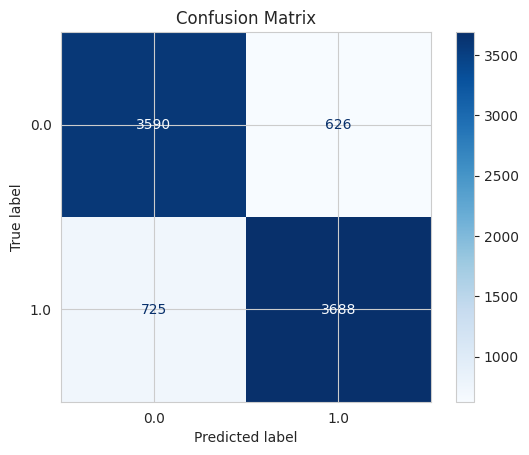


Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      4216
         1.0       0.85      0.84      0.85      4413

    accuracy                           0.84      8629
   macro avg       0.84      0.84      0.84      8629
weighted avg       0.84      0.84      0.84      8629



In [ ]:
# Creating a confusion matrix, with a display for better viewing
confusion = confusion_matrix(y_pred_tuned, y_val)
confusion_display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=np.unique(y_val))
confusion_display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Also creating a classification report to view precision, recall & F1 scores
class_report = classification_report(y_pred_tuned, y_val)
print("\nClassification Report:")
print(class_report)

In [ ]:
# Creating a copy of validation set and adding in predicted target to compare
results_val_df = X_val_ord.copy()
results_val_df['Actual Target'] = y_val_ord
results_val_df['Predicted Target'] = y_pred_tuned

# Comparing the incorrect predictions for each class of Gender
print('\nNumber of incorrect predictions given male gender:')
wrong_male = results_val_df[(results_val_df['Actual Target'] != results_val_df['Predicted Target'])&
               (results_val_df['gender_Male'] == True)]['Predicted Target'].count()
total_male = results_val_df[results_val_df['gender_Male'] == True]['Predicted Target'].count()
wrong_male_proportion = wrong_male / total_male
print(wrong_male, '(', '{:.2%} )'.format(wrong_male_proportion))

print('\nNumber of incorrect predictions not given gender:')
wrong_notprovided = results_val_df[(results_val_df['Actual Target'] != results_val_df['Predicted Target'])&
               (results_val_df['gender_Not Provided'] == True)]['Predicted Target'].count()
total_notprovided = results_val_df[results_val_df['gender_Not Provided'] == True]['Predicted Target'].count()
wrong_notprovided_proportion = wrong_notprovided / total_notprovided
print(wrong_notprovided, '(', '{:.2%} )'.format(wrong_notprovided_proportion))

print('\nNumber of incorrect predictions given other gender:')
wrong_other = results_val_df[(results_val_df['Actual Target'] != results_val_df['Predicted Target'])&
               (results_val_df['gender_Other'] == True)]['Predicted Target'].count()
total_other = results_val_df[results_val_df['gender_Other'] == True]['Predicted Target'].count()
wrong_other_proportion = wrong_other / total_other
print(wrong_other, '(', '{:.2%} )'.format(wrong_other_proportion))

print('\nNumber of incorrect predictions given female gender:')
wrong_female = results_val_df[(results_val_df['Actual Target'] != results_val_df['Predicted Target'])&
               ((results_val_df['gender_Male'] == False)&(results_val_df['gender_Not Provided'] == False)&(results_val_df['gender_Other'] == False))]['Predicted Target'].count()
total_female = results_val_df[(results_val_df['gender_Male'] == False)&(results_val_df['gender_Not Provided'] == False)&(results_val_df['gender_Other'] == False)]['Predicted Target'].count()
wrong_female_proportion = wrong_female / total_female
print(wrong_female, '(', '{:.2%} )'.format(wrong_female_proportion))


Number of incorrect predictions given male gender:
880 ( 14.96% )

Number of incorrect predictions not given gender:
375 ( 16.50% )

Number of incorrect predictions given other gender:
11 ( 13.41% )

Number of incorrect predictions given female gender:
86 ( 19.82% )


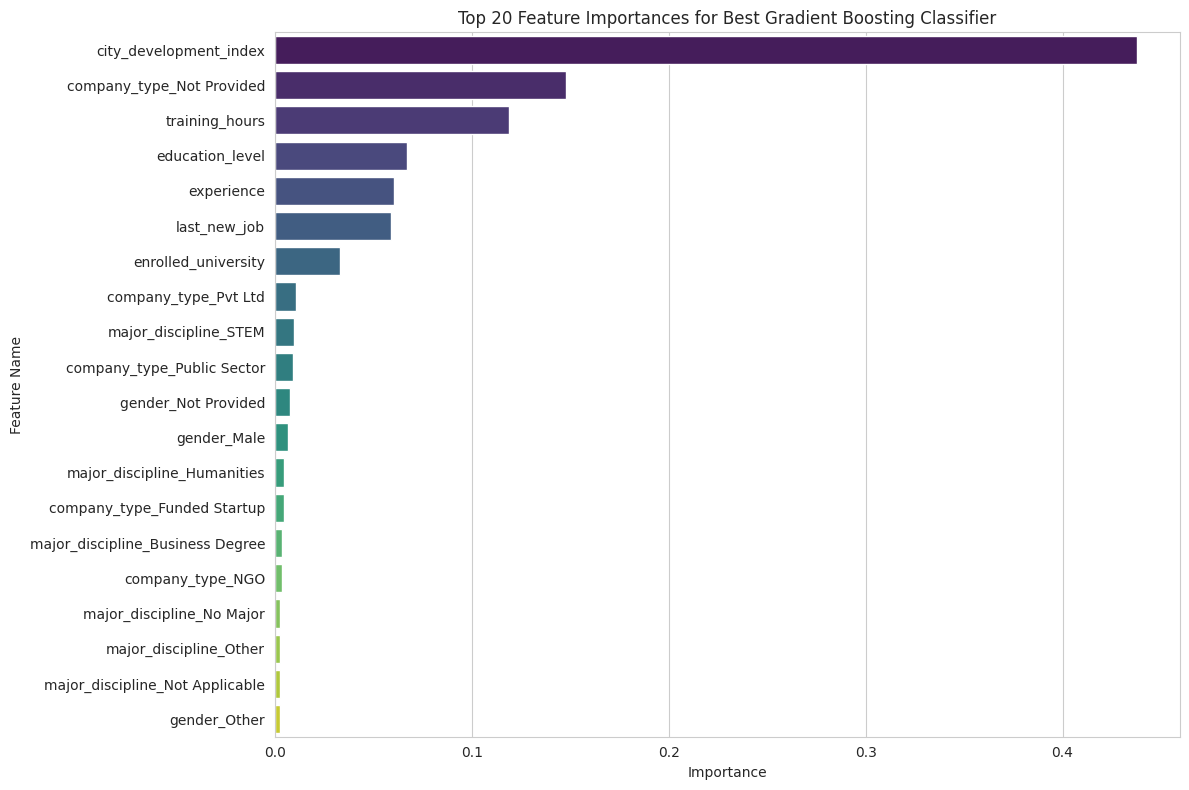

In [ ]:
# Selecting the GB Model from the list of best models
best_gb_model = best_models[1]

# Find the best GradientBoostingClassifier from best_models
best_model = best_gb_model['best_estimator']


# Getting feature importances and names
feature_importances = best_model.feature_importances_
feature_names = X_train_ord.columns

# Creating a DataFrame for better visualization
importance_df = pd.DataFrame({
     'Feature': feature_names,
     'Importance': feature_importances
 })
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Best Gradient Boosting Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# 8. Pipeline Creation and Execution

We can look to use the model created and fine-tuned above to create a pipeline function into which we can pass any (similar) dataset, perform all necessary preprocessing steps and then obtain a prediction at the end.

In [ ]:
def predict_pipeline(df):
  '''
  Combining all preprocessing steps as well as Target Prediction using Gradient Boosting Classifierinto a single function.

  Input : df (pandas dataframe containing rows of applicants who need to be classified as likely to leave their company or not)
  Output : Target Prediction for each applicant (0 or 1).
  '''

  # Making a copy to avoid modifying the original test dataframe
  df_processed = df.copy()

  # Normalisation of categorical fields
  # Re-defining the categorize_experience_to_ranges function to be local to the pipeline
  def categorize_experience_to_ranges_local(exp):
    try:
      # Converting strings to comparable ints
      exp_val = int(float(exp))
      if 1 <= exp_val <= 5:
        return '1-5'
      elif 6 <= exp_val <= 10:
         return '6-10'
      elif 11 <= exp_val <= 15:
         return '11-15'
      elif 16 <= exp_val <= 20:
         return '16-20'
      else:
         return str(exp) # Fallback for unexpected numeric values
    except ValueError:
      return str(exp) # Fallback for non-numeric values ('not provided' etc.)

  df_processed['experience'] = df_processed['experience'].apply(categorize_experience_to_ranges_local)
  df_processed.loc[df_processed['company_size']=='Oct-49', 'company_size'] = '10-49'

  # Imputation (matching previous steps in the notebook)
  df_processed['gender'].fillna('Not Provided', inplace=True)
  df_processed['enrolled_university'].fillna('Not Provided', inplace=True)
  df_processed['education_level'].fillna('Not Provided', inplace=True)
  df_processed.loc[(df_processed['education_level']=='High School') | (df_processed['education_level']=='Primary School'), 'major_discipline'] = 'Not Applicable'
  df_processed['major_discipline'].fillna('Not Provided', inplace=True)
  df_processed['experience'].fillna('Not Provided', inplace=True)
  df_processed['last_new_job'].fillna('Not Provided', inplace=True)
  df_processed['company_size'].fillna('Not Provided', inplace=True)
  df_processed['company_type'].fillna('Not Provided', inplace=True)

  # Store enrollee_ids before dropping the column for prediction
  # These will be used later to show which applicants are predicted to leave vs stay
  enrollee_ids = df_processed['enrollee_id']
  df_processed = df_processed.drop(columns=['enrollee_id'], errors='ignore')

  # Dropping 'city' column as this is correlated with 'city_development_index' and was dropped in training
  df_processed = df_processed.drop(columns=['city'], errors='ignore')

  # Scaling numerical variables
  scalar = StandardScaler()
  numerical_cols = df_processed.select_dtypes(include=['int64', 'float64'])
  numerical_cols = numerical_cols.columns.drop('target', errors='ignore')
  df_processed[numerical_cols] = scalar.fit_transform(df_processed[numerical_cols])

  # Ordinal Encoding
  ordered_levels = {
   'education_level' : ["Primary School", "High School", "Graduate", "Masters", "Phd"],
   'relevent_experience' : ["No_relevent_experience", "Has_relevent_experience"],
   'enrolled_university' : ["no_enrollment", "Part time course", "Full time course"],
   'experience' : ["<1", "1-5", "6-10", "11-15", "16-20", ">20"],
   'company_size' : ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "10000+"],
   'last_new_job' : ["never", "1", "2", "3", "4", ">4"]
  }

  for key, cats in ordered_levels.items():
    df_processed[key] = df_processed[key].astype(str)
    ord_enc = OrdinalEncoder(
        categories=[cats],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    df_processed[key] = ord_enc.fit_transform(df_processed[[key]])

  # One-Hot Encoding Categorical Variables
  nominal_cols = df_processed[['gender', 'company_type', 'major_discipline']].columns
  df_processed = pd.get_dummies(df_processed, columns=nominal_cols, drop_first=True)

  # Dropping city as was done in training
  df_processed = df_processed.drop(columns=['company_size'], errors='ignore')

  # Ensure the order of columns in the test set matches the training set
  df_processed = df_processed[X_train_ord.columns]

  # Data is ready, now we predict using GradientBoostingClassifier
  y_pred = best_model.predict(df_processed)

  # Add enrollee_id back and the predictions
  results_df = pd.DataFrame({'enrollee_id': enrollee_ids, 'target': y_pred})

  return results_df

In [ ]:
# Importing the test set to demonstrate the prediction function
df_test = pd.read_csv('aug_test.csv')

In [ ]:
# Running the function using the new test df
predict_pipeline(df_test)

,enrollee_id,target
0,32403,1.0
1,9858,1.0
2,31806,1.0
3,27385,0.0
4,27724,1.0
...,...,...
2124,1289,0.0
2125,195,1.0
2126,31762,0.0
2127,7873,1.0
